In [6]:
from numpy import *
from scipy.integrate import quad
from matplotlib.pyplot import plot
%matplotlib inline

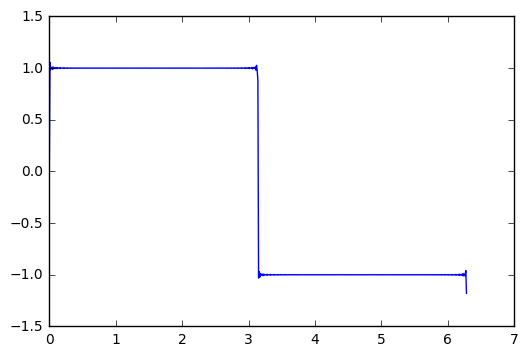

In [20]:
# Number of terms in the series
N = 1000

# Square wave Fourier coefficients
a0 = 0
a = zeros(N)
b = zeros(N)
for k in range(int(N/2)):
    b[2*k] = (4/pi)* 1/(2*k+1)

# Computation of series at gridpoits
x = arange(0,2*pi,0.01)
series = a0 * ones(x.size)
for k in range(N):
    series += a[k] * cos((k+1)*x) + b[k] * sin((k+1)*x)

# Graph
plot(x,series)

In [23]:
soma = 0
for i in range(3):
    soma += 4 * power(-1,i) / (2*i+1)
print(soma)
print(pi)

3.46666666667
3.141592653589793


In [9]:
def f(x):
    return x*x

quad(f,0,1)
# Computes the integral, or quadrature, of f from 0 to 1.
# Returns (v,e), where v is the value of the integral
# and e is and upper bound for the error
#
# Same result in one line:
# quad(lambda x : x*x, 0,1)

(0.33333333333333337, 3.700743415417189e-15)

In [10]:
def fourier_coef(f,N):
    '''Return the first 2*N+1 Fourier coefficients
    of a function.'''
    a = zeros(N)
    b = zeros(N)
    a0 = 1/(2*pi) * quad(f,0,2*pi)[0]
    for k in range(N):
        a[k] = (1/pi) * quad( lambda x : f(x)*cos((k+1)*x) ,0,2*pi)[0]
        b[k] = (1/pi) * quad( lambda x : f(x)*sin((k+1)*x) ,0,2*pi)[0]
    return (a0,a,b)

In [11]:
def fourier_series(f,N,x):
    '''Return the sum of the first 2N+1 terms
    of the Fourier series of f evaluated at 
    the components of the array x'''
    
    (a0,a,b) = fourier_coef(f,N)
    series = a0 * ones(x.size)
    for k in range(N):
        series += a[k] * cos((k+1)*x) + b[k] * sin((k+1)*x)
    return series

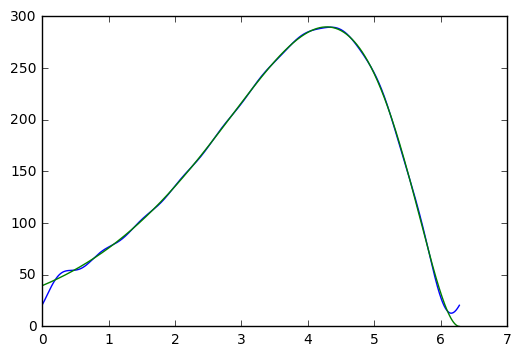

In [27]:
def f(x):
#   if x <= pi:
#       return 1
#   return -1
    return (2*pi-x)*(2*pi-x)*exp(x)
    
N = 10
x = arange(0,2*pi,0.01)
series = fourier_series(f,N,x)

y = zeros(x.size)
for i in range(y.size):
    y[i] = f(x[i])

plot(x,series)
plot(x,y)